<a href="https://colab.research.google.com/github/damasiami/Atividade-POO/blob/main/Trabalho_UBS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

In [ ]:
!pip install geopandas

In [ ]:
!pip install geopandas mapclassify --upgrade -q

In [ ]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from shapely.geometry import Point, LineString, Polygon

In [ ]:
!pip install GeoPandas

In [ ]:
!pip install geodatasets

In [ ]:
df = pd.read_csv('/content/Unidades_Basicas_Saude-UBS.csv',
sep=';',
encoding='latin1',
quotechar='"',
low_memory=False)
df

,CNES,UF,IBGE,NOME,LOGRADOURO,BAIRRO,LATITUDE,LONGITUDE
0,23914,31,310620,CENTRO DE SAUDE JARDIM MONTANHES,RUA SAUDE,PADRE EUSTAQUIO,-19.911503,"-43,9914089036"
1,106143,26,261000,UBS FRANCISCO VIEIRA DE MELO,QUADRA 50,QUILOMBO II,-8.705590,"-35,5995386839"
2,302,26,260290,USF SANTO ESTEVAO,RUA DO CEMITERIO,PONTE DOS CARVALHOS,-8.218112,"-35,2294359"
3,405132,26,261350,UNIDADE DE SAUDE SABINO LUCAS DE BARROS,TRAVESSA SAO PAULO,VILA DELMIRO,-7.866081,"-38,7650871277"
4,881007,26,261000,UBS MARIA ALICE,QUADRA 11,QUILOMBO 2,-8.698513,"-35,6040179729"
...,...,...,...,...,...,...,...,...
47668,9999078,31,310710,PRBE PRESIDIO DE BOA ESPERANCA,RUA MARIQUINHA GOMES,NOVA ERA,-21.090000,"-45,565"
47669,9999280,25,250070,EMAD II SAO JOAO DO RIO DO PEIXE,RUA LAURENIO FIRMEZA,CENTRO,-6.725174,"-38,4488010406"
47670,9999396,29,291072,UNIDADE BASICA DE SAUDE IRIS LOPES,RUA FABIA SPINDOLA,ROCA DO POVO,-16.312479,"-39,5957565308"
47671,9999493,41,410765,UNIDADE DE SAUDE SANTAREM,RUA NIGER,NACOES,-25.671526,"-49,2914700508"


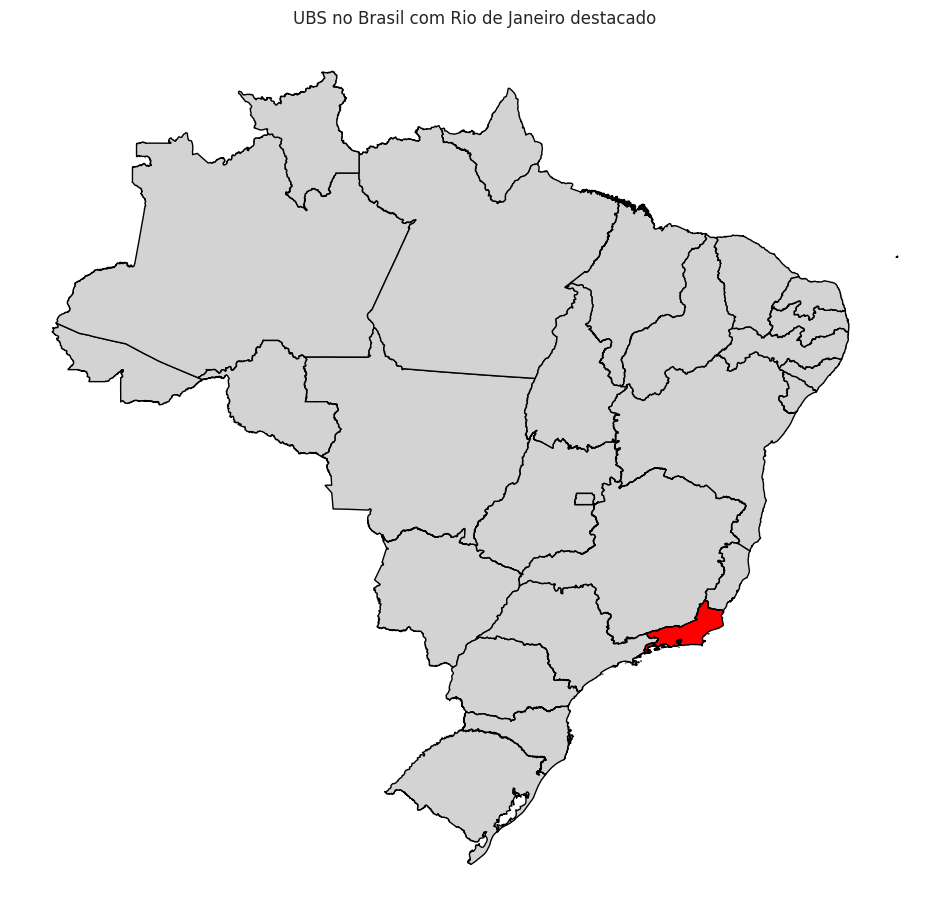

In [ ]:
%matplotlib inline

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np

dados = pd.read_csv(
    'Unidades_Basicas_Saude-UBS.csv',
    sep=';'
)

dados['LATITUDE'] = pd.to_numeric(dados['LATITUDE'], errors='coerce')
dados['LONGITUDE'] = pd.to_numeric(dados['LONGITUDE'], errors='coerce')

dados = dados.replace([np.inf, -np.inf], np.nan)

dados = dados.dropna(subset=['LATITUDE', 'LONGITUDE'])

dados = dados[
    (dados['LATITUDE'] >= -35) &
    (dados['LATITUDE'] <= 10) &
    (dados['LONGITUDE'] >= -75) &
    (dados['LONGITUDE'] <= -30)
]

geo = gpd.GeoDataFrame(
    dados,
    geometry=gpd.points_from_xy(
        dados['LONGITUDE'],
        dados['LATITUDE']
    ),
    crs='EPSG:4326'
)

url = "https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson"

brasil = gpd.read_file(url)

fig, ax = plt.subplots(figsize=(12, 12))

brasil['cor'] = 'lightgray'

brasil.loc[
    brasil['sigla'] == 'RJ',
    'cor'
] = 'red'

brasil.plot(
    ax=ax,
    color=brasil['cor'],
    edgecolor='black'
)

geo.plot(
    ax=ax,
    color='blue',
    markersize=2,
    aspect=1
)

rj = geo[geo['UF'] == 'RJ']

rj.plot(
    ax=ax,
    color='grenn',
    markersize=8,
    aspect=1
)

ax.set_title('UBS no Brasil com Rio de Janeiro destacado')

ax.axis('off')

plt.show()

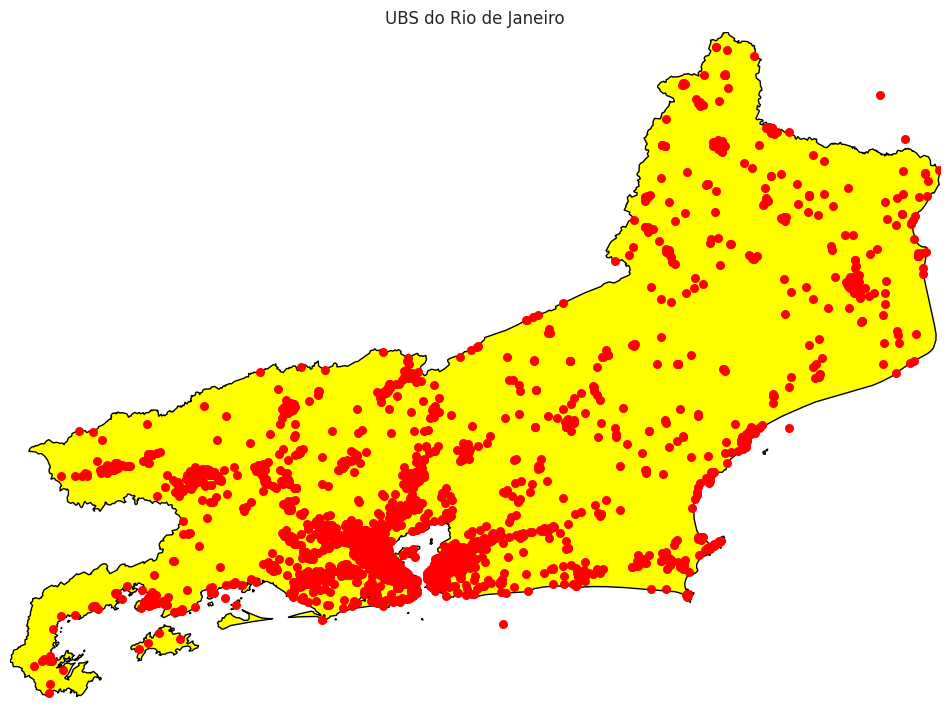

In [ ]:
%matplotlib inline

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

dados = pd.read_csv(
    'Unidades_Basicas_Saude-UBS.csv',
    sep=';'
)

dados['LATITUDE'] = (
    dados['LATITUDE']
    .astype(str)
    .str.replace(',', '.')
    .astype(float)
)

dados['LONGITUDE'] = (
    dados['LONGITUDE']
    .astype(str)
    .str.replace(',', '.')
    .astype(float)
)

rj = dados[dados['UF'] == 33]

url = "https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson"

brasil = gpd.read_file(url)

rj_mapa = brasil[brasil['sigla'] == 'RJ']

fig, ax = plt.subplots(figsize=(12, 12))

rj_mapa.plot(
    ax=ax,
    color='yellow',
    edgecolor='black'
)

ax.scatter(
    rj['LONGITUDE'].values,
    rj['LATITUDE'].values,
    color='red',
    s=30,
    zorder=5
)

xmin, ymin, xmax, ymax = rj_mapa.total_bounds

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

ax.set_title('UBS do Rio de Janeiro')

ax.axis('off')

plt.show()

In [12]:
rj = dados[dados['UF'] == 33]

print('Total de UBS no Rio de Janeiro:', len(rj))

Total de UBS no Rio de Janeiro: 2370


In [13]:
top10 = rj['NOME'].value_counts().head(10)

print(top10)

NOME
ESF CENTRO                                           4
CONSULTORIO NA RUA                                   3
UBS CENTRO                                           3
ESF GUARANI                                          2
UNIDADE BASICA DE SAUDE RETIRO                       2
UNIDADE DE SAUDE DA FAMILIA DO PANTANAL              2
UNIDADE DE SAUDE DA FAMILIA CENTRO                   2
UNIDADE SAUDE DA FAMILIA DR VIRTO VIEIRA DE SOUZA    2
ESF BOTAFOGO                                         2
UNIDADE DE SAUDE DA FAMILIA DE SAO FRANCISCO         2
Name: count, dtype: int64


<Axes: title={'center': '10 municípios com mais UBS no RJ'}, xlabel='NOME'>

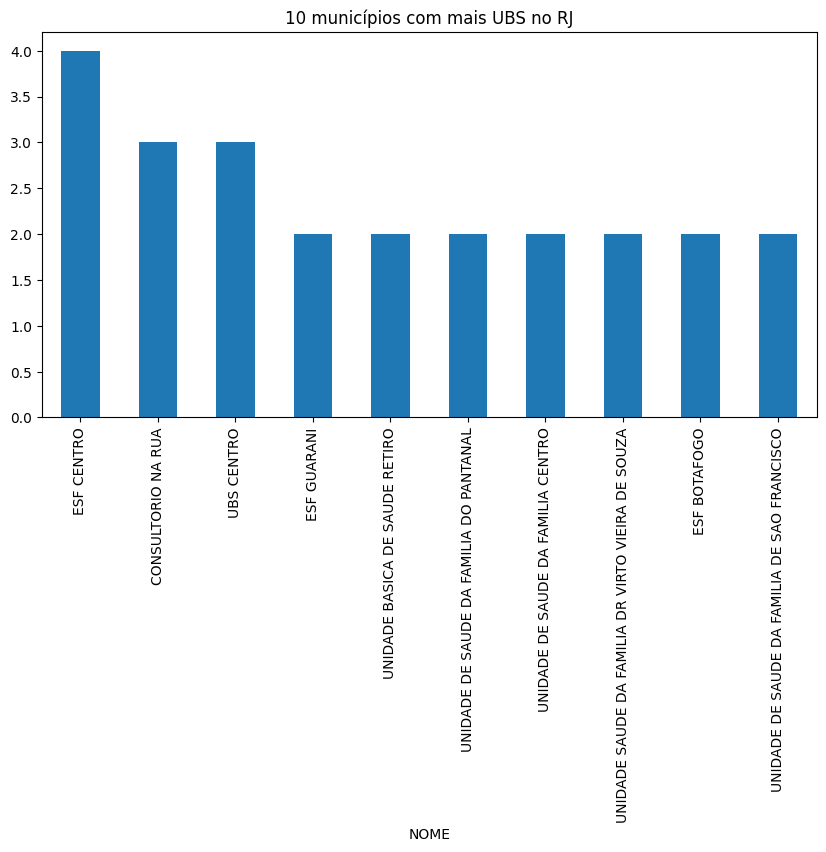

In [14]:
top10.plot(
    kind='bar',
    figsize=(10,5),
    title='10 municípios com mais UBS no RJ'
)

In [15]:
menos10 = rj['NOME'].value_counts().tail(10)

print(menos10)

NOME
ESF MORRO DE SAO JORGE                            1
ESF MALVINAS B                                    1
ESF MALVINAS AC                                   1
NUCLEO ATENCAO SAUDE DA MULHER E CRIANCA BARRA    1
ESF NOVA HOLANDA AB                               1
UBS BICUDA GRANDE                                 1
ESF ENGENHO DA PRAIA                              1
CENTRO DE SAUDE MOACYR SANTOS                     1
UBS MORRO DE SANTANA                              1
ESF GLICERIO                                      1
Name: count, dtype: int64


In [21]:
media = rj['NOME'].value_counts().mean()

acima_media = rj['NOME'].value_counts()

acima_media = acima_media[acima_media > media]

print(acima_media)

NOME
ESF CENTRO                                                      4
CONSULTORIO NA RUA                                              3
UBS CENTRO                                                      3
ESF GUARANI                                                     2
UNIDADE BASICA DE SAUDE RETIRO                                  2
UNIDADE DE SAUDE DA FAMILIA DO PANTANAL                         2
UNIDADE DE SAUDE DA FAMILIA CENTRO                              2
UNIDADE SAUDE DA FAMILIA DR VIRTO VIEIRA DE SOUZA               2
ESF BOTAFOGO                                                    2
UNIDADE DE SAUDE DA FAMILIA DE SAO FRANCISCO                    2
UNIDADE DE SAUDE DA FAMILIA DO CENTRO                           2
UNIDADE DE SAUDE DA FAMILIA BOA VISTA                           2
UNIDADE DE SAUDE DA FAMILIA DE TARITUBA                         2
UNIDADE DE SAUDE DA FAMILIA DO CAMPINHO                         2
SUBSECRETARIA DE ATENCAO BASICA                                 2
UNIDA

<Axes: title={'center': 'Distribuição de UBS por município'}, ylabel='Frequency'>

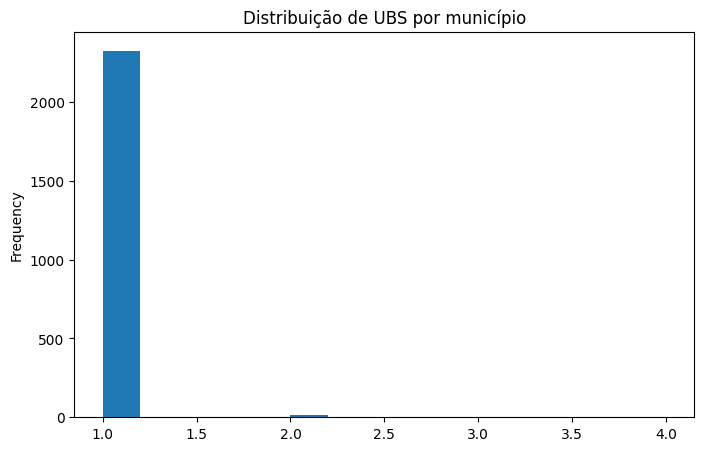

In [18]:
rj['NOME'].value_counts().plot(
    kind='hist',
    bins=15,
    figsize=(8,5),
    title='Distribuição de UBS por município'
)

In [22]:
media = rj['NOME'].value_counts().mean()

print(media)

1.010230179028133


In [23]:
media = rj['NOME'].value_counts().mean()

acima_media = rj['NOME'].value_counts()

acima_media = acima_media[acima_media > media]

print(acima_media)

NOME
ESF CENTRO                                                      4
CONSULTORIO NA RUA                                              3
UBS CENTRO                                                      3
ESF GUARANI                                                     2
UNIDADE BASICA DE SAUDE RETIRO                                  2
UNIDADE DE SAUDE DA FAMILIA DO PANTANAL                         2
UNIDADE DE SAUDE DA FAMILIA CENTRO                              2
UNIDADE SAUDE DA FAMILIA DR VIRTO VIEIRA DE SOUZA               2
ESF BOTAFOGO                                                    2
UNIDADE DE SAUDE DA FAMILIA DE SAO FRANCISCO                    2
UNIDADE DE SAUDE DA FAMILIA DO CENTRO                           2
UNIDADE DE SAUDE DA FAMILIA BOA VISTA                           2
UNIDADE DE SAUDE DA FAMILIA DE TARITUBA                         2
UNIDADE DE SAUDE DA FAMILIA DO CAMPINHO                         2
SUBSECRETARIA DE ATENCAO BASICA                                 2
UNIDA

In [29]:
alta_renda = [
    'BARRA DA TIJUCA',
    'LEBLON',
    'IPANEMA'
]

baixa_renda = [
    'COMPLEXO DO ALEMAO',
    'BANGU',
    'BELFORD ROXO'
]

ubs_alta = rj['BAIRRO'].isin(alta_renda).sum()

ubs_baixa = rj['BAIRRO'].isin(baixa_renda).sum()

print('UBS em áreas de Classe alta:', ubs_alta)

print('UBS em áreas de Classe baixa:', ubs_baixa)

UBS em áreas de Classe alta: 14
UBS em áreas de Classe baixa: 42


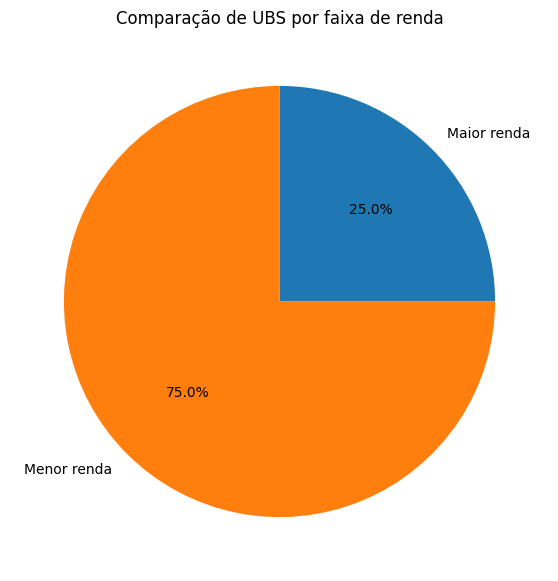

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

comparacao = pd.Series({
    'Maior renda': ubs_alta,
    'Menor renda': ubs_baixa
})

comparacao.plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(7,7)
)

plt.title('Comparação de UBS por faixa de renda')

plt.ylabel('')

plt.show()

In [32]:
rj_total = dados[dados['UF'] == 33].shape[0]

sc_total = dados[dados['UF'] == 42].shape[0]

print('UBS no Rio de Janeiro:', rj_total)

print('UBS em Santa Catarina:', sc_total)

UBS no Rio de Janeiro: 2370
UBS em Santa Catarina: 2055


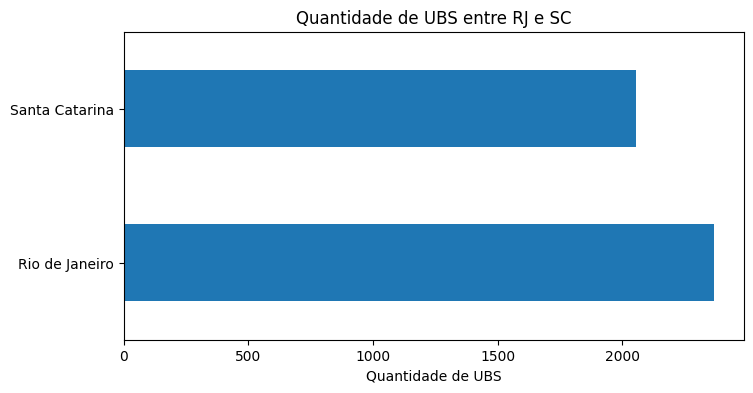

In [36]:
import pandas as pd
import matplotlib.pyplot as plt

rj_total = dados[dados['UF'] == 33].shape[0]

sc_total = dados[dados['UF'] == 42].shape[0]

comparacao = pd.Series({
    'Rio de Janeiro': rj_total,
    'Santa Catarina': sc_total
})

comparacao.plot(
    kind='barh',
    figsize=(8,4)
)

plt.title('Quantidade de UBS entre RJ e SC')

plt.xlabel('Quantidade de UBS')

plt.show()